In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

# print("Path to dataset files:", path)

In [2]:
dataset_link = ''

### 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision import models

In [5]:
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report
from sklearn.model_selection import train_test_split

In [6]:
from pathlib import Path
import os
from PIL import Image

In [7]:
from tqdm import tqdm
import time

In [8]:
# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Setting Directories

In [9]:
train_dir = Path('train')
test_dir = Path('test')

In [10]:
train_dir.is_dir(), test_dir.is_dir()

(True, True)

In [11]:
#list all paths inside train and test directories
train_all_path = list(train_dir.glob('*.jpg'))
len(train_all_path)

6499

In [12]:
test_all_path = list(test_dir.glob('*.jpg'))
len(test_all_path)

2786

In [13]:
train_csv = 'Training_set.csv'
test_csv = 'Testing_set.csv'

### Data Preparation

In [14]:
train_df = pd.read_csv(train_csv)
train_df

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART
...,...,...
6494,Image_6495.jpg,MANGROVE SKIPPER
6495,Image_6496.jpg,MOURNING CLOAK
6496,Image_6497.jpg,APPOLLO
6497,Image_6498.jpg,ELBOWED PIERROT


In [15]:
test_df = pd.read_csv(test_csv)
test_df

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg
...,...
2781,Image_2782.jpg
2782,Image_2783.jpg
2783,Image_2784.jpg
2784,Image_2785.jpg


In [16]:
len(train_all_path) == len(train_df) #check if csv contain all images inside train_directory?![as numbers, you can go deeper by checking if file names exist on the dataframe csv]

True

In [17]:
len(test_all_path) == len(test_df)

True

In [18]:
class_counts = train_df['label'].value_counts().sort_values(ascending=False)
class_counts

label
MOURNING CLOAK    131
SLEEPY ORANGE     107
ATALA             100
BROWN SIPROETA     99
SCARCE SWALLOW     97
                 ... 
AMERICAN SNOOT     74
GOLD BANDED        73
MALACHITE          73
CRIMSON PATCH      72
WOOD SATYR         71
Name: count, Length: 75, dtype: int64

In [19]:
print(f"Min samples per class: {class_counts.min()}") # 71
print(f"Max samples per class: {class_counts.max()}") # 131
print(f"Mean samples per class: {class_counts.mean():.1f}") # 86.7


Min samples per class: 71
Max samples per class: 131
Mean samples per class: 86.7


In [20]:
# Get class names
class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
print(f"Total classes: {num_classes}") # 75
print(f"First 10 classes: {class_names[:10]}") # ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK']

Total classes: 75
First 10 classes: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK']


### EDA

In [21]:
train_df['Duplicate'] = train_df.duplicated()

In [22]:
train_df[train_df['Duplicate']] #if empy then no duplicates are there 

,filename,label,Duplicate


In [23]:
train_df[(train_df.index != train_df.index) & (train_df.filename == train_df.filename) ] #check if we are having same filename with different label

,filename,label,Duplicate


In [24]:
# Now after we haved check data we are having the green light to drop the duplicate column
train_df.drop('Duplicate',  axis = 1,inplace = True)

In [25]:
train_df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [26]:
train_df['path'] = train_df['filename'].apply(lambda f: os.path.join(train_dir, f))
test_df['path'] = test_df['filename'].apply(lambda f: os.path.join(test_dir, f))

In [27]:
test_df.head()

,filename,path
0,Image_1.jpg,test/Image_1.jpg
1,Image_2.jpg,test/Image_2.jpg
2,Image_3.jpg,test/Image_3.jpg
3,Image_4.jpg,test/Image_4.jpg
4,Image_5.jpg,test/Image_5.jpg


#### check image size and if they vary

In [28]:
random_path_list = train_df.sample(16)

In [29]:
random_path_list

,filename,label,path
5903,Image_5904.jpg,ORCHARD SWALLOW,train/Image_5904.jpg
4961,Image_4962.jpg,CRIMSON PATCH,train/Image_4962.jpg
4062,Image_4063.jpg,DANAID EGGFLY,train/Image_4063.jpg
2040,Image_2041.jpg,PAINTED LADY,train/Image_2041.jpg
2388,Image_2389.jpg,RED ADMIRAL,train/Image_2389.jpg
5811,Image_5812.jpg,MILBERTS TORTOISESHELL,train/Image_5812.jpg
2725,Image_2726.jpg,CRECENT,train/Image_2726.jpg
4582,Image_4583.jpg,SLEEPY ORANGE,train/Image_4583.jpg
1982,Image_1983.jpg,MOURNING CLOAK,train/Image_1983.jpg
5254,Image_5255.jpg,SCARCE SWALLOW,train/Image_5255.jpg


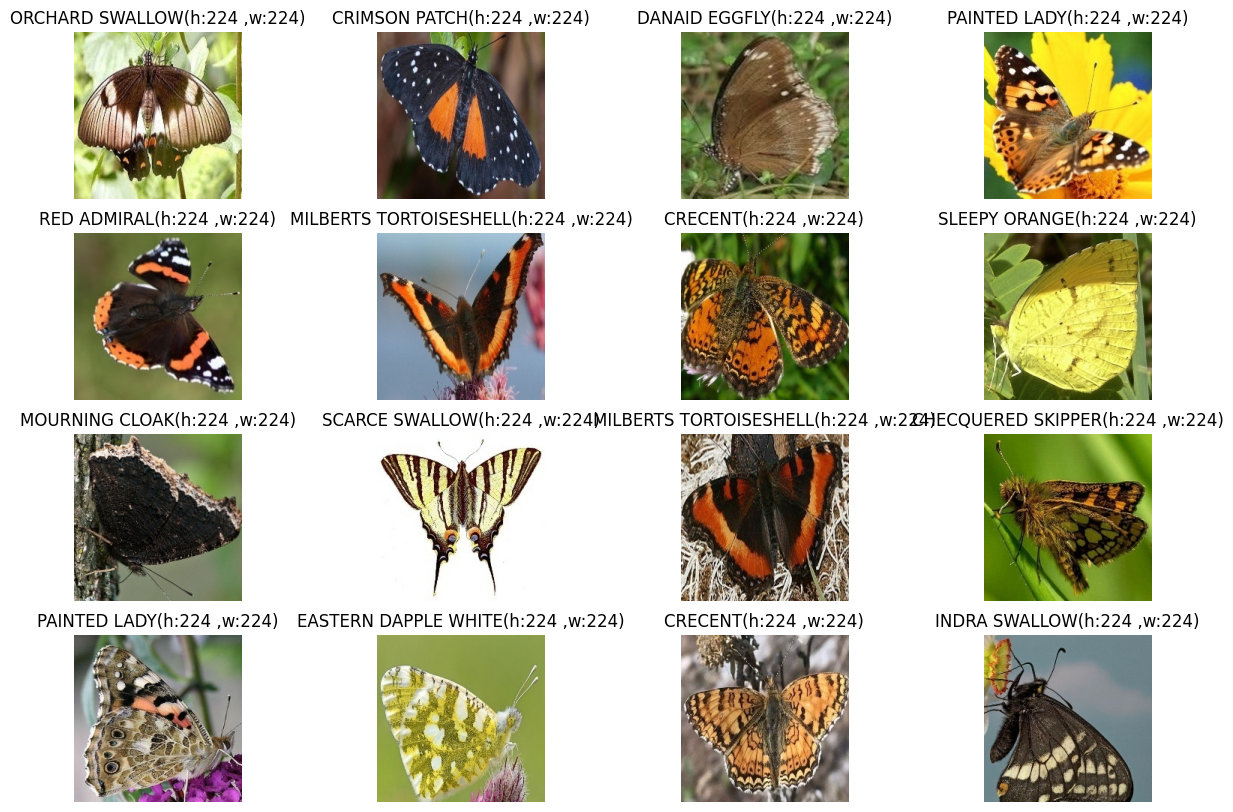

In [30]:
fig , axes = plt.subplots(4 , 4 , figsize = (15 , 10))
axes = axes.flatten()
for i , ax in enumerate(axes):
    ax.imshow(plt.imread(random_path_list.iloc[i]['path']))
    img =  Image.open(random_path_list.iloc[i]['path'])
    ax.set_title(f"{random_path_list.iloc[i].label}(h:{img.height} ,w:{img.width})")
    ax.set_axis_off()
   

### 3. Custom Dataset class

In [31]:
class ButterflyDataset(Dataset):
    def __init__(self, df, img_dir, transform = None, is_test = False):
        """
        Custom dataset for butterfly images.
        
        Args:
            df: DataFrame with 'filename' and optionally 'label' columns
            img_dir: Directory containing images
            transform: Image transformations
            is_test: Whether this is the test set (no labels)
        """
        self.df = df
        self.img_dir = img_dir 
        self.transform = transform 
        self.is_test = is_test 

        # Create label to index mapping 
        if not is_test:
            self.label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
            self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        # Load image 
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_name 
        else:
            label = self.df.iloc[idx]['label']
            label_idx = self.label_to_idx[label]
            return image, label_idx
            

### 4. Data Transforms and Loaders

In [32]:
# Define image size - butterfly images may vary
img_size = 224  # Standard size for many pretrained models

# Data transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# create datasets 
img_dir = 'train'

train_dataset = ButterflyDataset(
    df = train_df,
    img_dir = img_dir,
    transform = train_transform,
    is_test = False
)

test_dataset = ButterflyDataset(
    df = test_df,
    img_dir = 'test',
    transform = test_transform,
    is_test = True 
)

print(f"Training dataset size: {len(train_dataset)}") # 6499
print(f"Test dataset size: {len(test_dataset)}") # 2786

Training dataset size: 6499
Test dataset size: 2786


### 5. Train-Validation Split

In [33]:
# Split training data into train and validation (80-20)
train_indices, val_indices = train_test_split(
    range(len(train_dataset)),
    test_size = 0.2,
    stratify = train_df['label'],
    random_state = 1234
)

train_subset = torch.utils.data.Subset(train_dataset, train_indices)
val_subset = torch.utils.data.Subset(train_dataset, val_indices)

print(f"Data split:")
print(f"  Training samples: {len(train_subset)}") # 5199
print(f"  Validation samples: {len(val_subset)}") # 1300 
print(f"  Test samples: {len(test_dataset)}") # 2786


Data split:
  Training samples: 5199
  Validation samples: 1300
  Test samples: 2786


In [34]:
# Data Loaders

batch_size = 32

train_loader = DataLoader(
    train_subset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

val_loader = DataLoader(
    val_subset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

test_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

print(f"Training batches: {len(train_loader)}") # 163
print(f"Validation batches: {len(val_loader)}") # 41
print(f"Test batches: {len(test_loader)}") # 204

Training batches: 163
Validation batches: 41
Test batches: 204


In [35]:
# Examie a sample batch 
sample_batch = next(iter(train_loader))
images, labels = sample_batch

print(f"Batch Analysis:")
print(f"Images tensor shape: {images.shape}") # torch.Size([32, 3, 224, 224])
print(f"Labels tensor shape: {labels.shape}") # torch.Size([32])
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]") # [-2.118, 2.640]

/home/kriti/Desktop/VSCode/ML with SciKit/.env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Analysis:
Images tensor shape: torch.Size([32, 3, 224, 224])
Labels tensor shape: torch.Size([32])
Image value range: [-2.118, 2.640]


### 6. Model Architecture

In [36]:
class ButterflyMLP(nn.Module):
    """
    Multi-Layer Perceptron for Butterfly Classification
    Architecture: 224×224×3 → 150528 → 512 → 256 → num_classes
    """
    
    def __init__(self, input_size=224*224*3, hidden1_size=512, hidden2_size=256, num_classes=75):
        super(ButterflyMLP, self).__init__()
        
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(input_size, hidden1_size)
        self.hidden2 = nn.Linear(hidden1_size, hidden2_size)
        self.output = nn.Linear(hidden2_size, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        self.batchnorm1 = nn.BatchNorm1d(hidden1_size)
        self.batchnorm2 = nn.BatchNorm1d(hidden2_size)
        
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.num_classes = num_classes
        
    def forward(self, x):
        x = self.flatten(x)

        x = self.hidden1(x)
        x = self.batchnorm1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        logits = self.output(x)
        return logits
    
    def get_model_info(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        info = {
            'Architecture': f'{self.input_size//1000}k → {self.hidden1_size} → {self.hidden2_size} → {self.num_classes}', # 150k → 512 → 256 → 75
            'Total Parameters': f'{total_params:,}', # 77,222,987
            'Trainable Parameters': f'{trainable_params:,}', # 77,222,987
            'Model Size (MB)': f'{total_params * 4 / (1024**2):.2f}', # 294.58 MB
        }
        return info

### 7. Model Initialization

In [37]:
print("Creating Butterfly MLP model")
model = ButterflyMLP(num_classes=num_classes).to(device)

print(f"\nModel Architecture:")
print(model)

model_info = model.get_model_info()
print(f"\nModel Statistics:")
for key, value in model_info.items():
    print(f"  {key}: {value}")

Creating Butterfly MLP model

Model Architecture:
ButterflyMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=150528, out_features=512, bias=True)
  (hidden2): Linear(in_features=512, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=75, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (batchnorm1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)

Model Statistics:
  Architecture: 150k → 512 → 256 → 75
  Total Parameters: 77,222,987
  Trainable Parameters: 77,222,987
  Model Size (MB): 294.58


In [38]:
# Test forward pass
print(f"Testing forward pass:")
with torch.no_grad():
    sample_input = torch.randn(32, 3, 224, 224).to(device)
    output = model(sample_input)
    print(f"  Input shape: {sample_input.shape}")
    print(f"  Output shape: {output.shape}")

    probabilities = F.softmax(output, dim = 1)
    print(f"  Probability sum per sample: {probabilities.sum(dim=1)[0]:.3f} (should be ~1.0)")



Testing forward pass:
  Input shape: torch.Size([32, 3, 224, 224])
  Output shape: torch.Size([32, 75])
  Probability sum per sample: 1.000 (should be ~1.0)


### 8. Training Setup

In [39]:
learning_rate = 0.001
num_epochs = 20
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 3)

print(f"Training Configuration:")
print(f"  Learning Rate: {learning_rate}") # 0.001
print(f"  Number of Epochs: {num_epochs}") # 20
print(f"  Optimizer: Adam with weight decay {weight_decay}") # 0.0001
print(f"  Loss Function: Cross-Entropy Loss")
print(f"  Batch Size: {batch_size}") # 32
print(f"  Learning Rate Scheduler: ReduceLROnPlateau")

Training Configuration:
  Learning Rate: 0.001
  Number of Epochs: 20
  Optimizer: Adam with weight decay 0.0001
  Loss Function: Cross-Entropy Loss
  Batch Size: 32
  Learning Rate Scheduler: ReduceLROnPlateau


### 9. Helper Functions

In [40]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    return 100 * correct / total 

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0 

    for batch_idx, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        accuracy = calculate_accuracy(outputs, labels)
        total_loss += loss.item()
        total_accuracy += accuracy 
        num_batches += 1

        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"    Batch [{batch_idx+1}/{len(dataloader)}] Loss: {loss.item():.4f}, Acc: {accuracy:.2f}%")

    avg_loss = total_loss / num_batches 
    avg_accuracy = total_accuracy / num_batches 
    return avg_loss, avg_accuracy

def evaluate_model(model, dataloader, criterion, device)    :
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            accuracy = calculate_accuracy(outputs, labels)
            total_loss += loss.item()
            total_accuracy += accuracy 
            num_batches += 1 

            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / num_batches 
    avg_accuracy = total_accuracy / num_batches 
    return avg_loss, avg_accuracy, all_predictions, all_labels       

### 10. Training Loop

In [41]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0

start_time = time.time()

for epoch in range(num_epochs):

    epoch_start_time = time.time()

    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # adjust learning rate 
    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start_time

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.2f}%")
    print(f"Time: {epoch_time:.2f}s")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model 
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_butterfly_model.pth')
        print(f"New best model saved! (Val Acc: {val_accuracy:.2f}%)")

total_time = time.time() - start_time
print("Training completed")
print(f"Total training time: {total_time:.2f}s ({total_time/60:.1f} minutes)")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Final validation accuracy: {val_accuracies[-1]:.2f}%")

    Batch [50/163] Loss: 4.0087, Acc: 0.00%
    Batch [100/163] Loss: 3.5805, Acc: 15.62%
    Batch [150/163] Loss: 3.9673, Acc: 9.38%
Train Loss: 3.9479 | Train Accuracy: 6.75%
Val Loss:   3.5114 | Val Accuracy:   13.78%
Time: 132.83s
Learning Rate: 0.001000
New best model saved! (Val Acc: 13.78%)
    Batch [50/163] Loss: 3.7007, Acc: 3.12%
    Batch [100/163] Loss: 3.3410, Acc: 18.75%
    Batch [150/163] Loss: 3.4848, Acc: 9.38%
Train Loss: 3.4160 | Train Accuracy: 14.04%
Val Loss:   3.1965 | Val Accuracy:   17.24%
Time: 132.76s
Learning Rate: 0.001000
New best model saved! (Val Acc: 17.24%)
    Batch [50/163] Loss: 2.8419, Acc: 12.50%
    Batch [100/163] Loss: 3.1637, Acc: 15.62%
    Batch [150/163] Loss: 2.9165, Acc: 15.62%
Train Loss: 3.2123 | Train Accuracy: 17.42%
Val Loss:   3.0348 | Val Accuracy:   22.64%
Time: 134.54s
Learning Rate: 0.001000
New best model saved! (Val Acc: 22.64%)
    Batch [50/163] Loss: 3.1963, Acc: 12.50%
    Batch [100/163] Loss: 3.1997, Acc: 21.88%
    B

### 11. Evaluation on Validation Set

In [42]:
# Load best model 
model.load_state_dict(torch.load('best_butterfly_model.pth'))

final_val_loss, final_val_accuracy, all_predictions, all_labels = evaluate_model(model, val_loader, criterion, device)

predictions = np.array(all_predictions)
true_labels = np.array(all_labels)

# Get class names for evaluation 
idx_to_label = train_dataset.idx_to_label
class_names_eval = [idx_to_label[i] for i in range(num_classes)]

print('\nClassification Report')
print(classification_report(true_labels, predictions, target_names = class_names))

# Per class accuracy 
class_accuracies = []
for i in range(num_classes):
    class_mask = (true_labels == i)
    if np.sum(class_mask) > 0: 
        class_arc = np.mean(predictions[class_mask] == true_labels[class_mask]) * 100
        class_accuracies.append(class_arc)

# Confusion Matrix 
cm = confusion_matrix(true_labels, predictions)

print(f"\nDetailed Performance Analysis:")
print(f"  Overall Accuracy: {final_val_accuracy:.2f}%")
print(f"  Best performing class: {class_names_eval[np.argmax(class_accuracies)]} ({max(class_accuracies):.1f}%)")
print(f"  Worst performing class: {class_names_eval[np.argmin(class_accuracies)]} ({min(class_accuracies):.1f}%)")

balanced_accuracy = np.mean([acc for acc in class_accuracies if acc > 0])
print(f"  Balanced accuracy: {balanced_accuracy:.2f}%")

/home/kriti/Desktop/VSCode/ML with SciKit/.env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Classification Report
                           precision    recall  f1-score   support

                   ADONIS       0.75      0.83      0.79        18
AFRICAN GIANT SWALLOWTAIL       0.64      0.60      0.62        15
           AMERICAN SNOOT       0.00      0.00      0.00        15
                    AN 88       0.32      0.41      0.36        17
                  APPOLLO       0.50      0.39      0.44        18
                    ATALA       0.35      0.40      0.37        20
 BANDED ORANGE HELICONIAN       0.42      0.25      0.31        20
           BANDED PEACOCK       1.00      0.29      0.45        17
            BECKERS WHITE       0.40      0.12      0.19        16
         BLACK HAIRSTREAK       0.25      0.18      0.21        17
              BLUE MORPHO       0.50      0.27      0.35        15
        BLUE SPOTTED CROW       0.18      0.12      0.14        17
           BROWN SIPROETA       0.17      0.35      0.23        20
            CABBAGE WHITE       0.29  

### 12. Confidence Analysis

In [43]:
model.eval()
all_confidences = []
correct_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = F.softmax(outputs, dim = 1)
        max_probs, predicted = torch.max(probabilities, 1)

        all_confidences.extend(max_probs.cpu().numpy())
        correct_predictions.extend((predicted == labels).cpu().numpy())

confidences = np.array(all_confidences)
correct = np.array(correct_predictions)

correct_confidences = confidences[correct]
incorrect_confidences = confidences[~correct]

print(f"\nConfidence Analysis:")
print(f"  Average confidence (correct): {np.mean(correct_confidences):.3f}")
if len(incorrect_confidences) > 0:
    print(f"  Average confidence (incorrect): {np.mean(incorrect_confidences):.3f}")
    
# High confidence errors
high_conf_errors = confidences[~correct] > 0.8
if len(incorrect_confidences) > 0:
    print(f"  High-confidence errors: {np.sum(high_conf_errors)} ({np.sum(high_conf_errors)/np.sum(~correct)*100:.1f}% of errors)")

/home/kriti/Desktop/VSCode/ML with SciKit/.env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Confidence Analysis:
  Average confidence (correct): 0.418
  Average confidence (incorrect): 0.220
  High-confidence errors: 0 (0.0% of errors)


### 13. Predictions on Test Set

In [44]:
model.eval()
test_predictions = []
test_filenames  = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        test_predictions.extend(predicted.cpu().numpy())
        test_filenames.extend(filenames)

# Map predictions back to class labels 
idx_to_label = train_dataset.idx_to_label
predicted_labels = [idx_to_label[idx] for idx in test_predictions]

# Create submissions DataFrame 
submission_df = pd.DataFrame({
    'filename': test_filenames,
    'labels': predicted_labels
})

print(f"\nTest predictions shape: {submission_df.shape}")
print(f"Test predictions head:")
print(submission_df.head())

# Save submission
submission_df.to_csv('submission.csv', index=False)
print("\nSubmission saved to 'submission.csv'")


Test predictions shape: (6499, 2)
Test predictions head:
     filename                    labels
0  tensor(66)                 CLEOPATRA
1   tensor(0)                    ADONIS
2  tensor(12)            BROWN SIPROETA
3  tensor(44)           CAIRNS BIRDWING
4  tensor(33)  GREEN CELLED CATTLEHEART

Submission saved to 'submission.csv'


### 14. Training Summary

Model successfully trained!
   Final Validation Accuracy: 34.16%
   Best Validation Accuracy: 34.48%
   Training Time: 2684.63s (44.7 minutes)
   Overfitting gap: -0.50%
   Good generalization (minimal overfitting)

Model Architecture: 150k → 512 → 256 → 75
Total Parameters: 77,222,987
Number of Classes: 75

Dataset Statistics:
  Training samples: 5199
  Validation samples: 1300
  Test samples: 2786
  Classes: 75


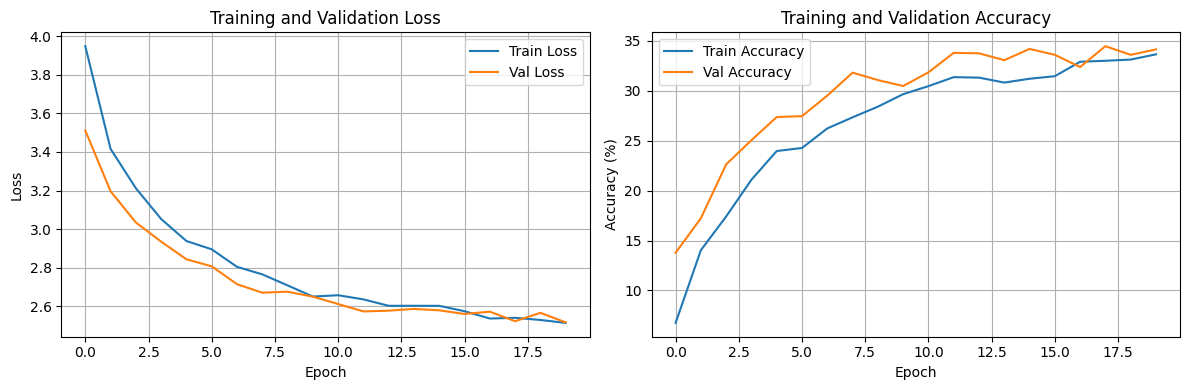

In [45]:
print(f"Model successfully trained!")
print(f"   Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"   Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"   Training Time: {total_time:.2f}s ({total_time/60:.1f} minutes)")
print(f"   Overfitting gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")

if train_accuracies[-1] - val_accuracies[-1] > 10:
    print("   Significant overfitting detected - consider more regularization")
elif train_accuracies[-1] - val_accuracies[-1] > 5:
    print("   Mild overfitting detected")
else:
    print("   Good generalization (minimal overfitting)")

print(f"\nModel Architecture: {model_info['Architecture']}")
print(f"Total Parameters: {model_info['Total Parameters']}")
print(f"Number of Classes: {num_classes}")

print(f"\nDataset Statistics:")
print(f"  Training samples: {len(train_subset)}")
print(f"  Validation samples: {len(val_subset)}")
print(f"  Test samples: {len(test_dataset)}")
print(f"  Classes: {num_classes}")

# Plot training curves 
if 'plt' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

    ax1.plot(train_losses, label = 'Train Loss')
    ax1.plot(val_losses, label = 'Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accuracies, label = 'Train Accuracy')
    ax2.plot(val_accuracies, label = 'Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

### 15. Sample Visualizations

/home/kriti/Desktop/VSCode/ML with SciKit/.env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


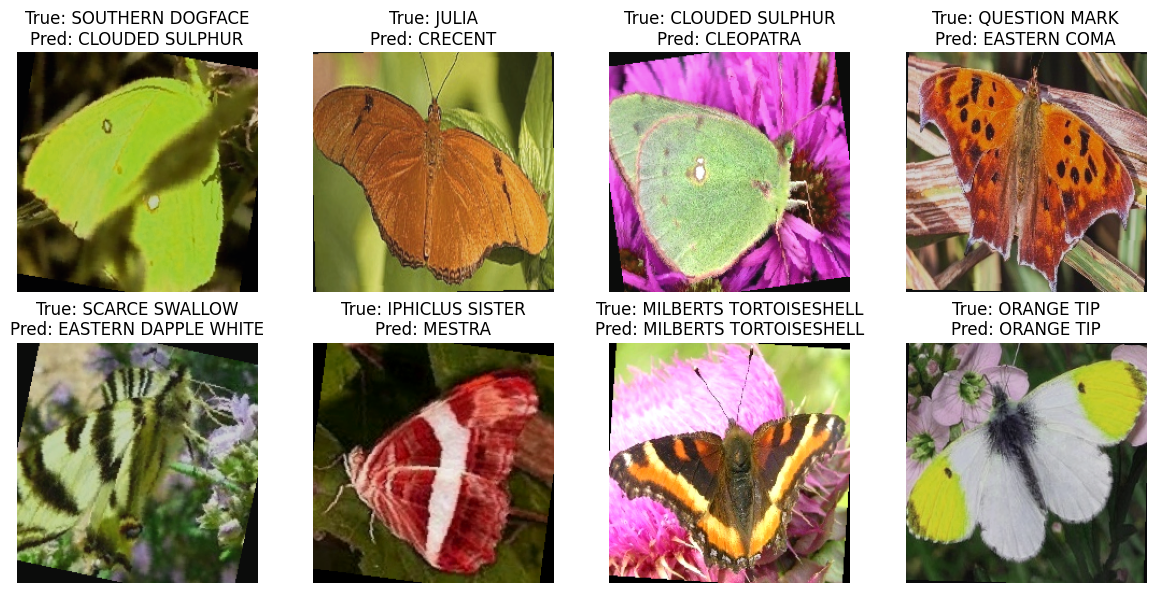

In [46]:
def show_sample_predictions(model, dataloader, class_names, num_samples = 8):
    '''Display sample images with their predictions'''
    model.eval()

    # Get a batch of images 
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

    # Convert to CPU for visualization
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()

    # Plot samples
    fig, axes = plt.subplots(2, 4, figsize = (12, 6))
    axes = axes.flatten()

    for idx in range(min(num_samples, len(images))):
        # Denormalize image 
        img = images[idx].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean 
        img = np.clip(img, 0, 1)

        axes[idx].imshow(img)
        axes[idx].set_title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predictions[idx]]}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Uncomment to display sample predictions
show_sample_predictions(model, val_loader, class_names_eval)

## Comparative  Study: Multiple CNN Architectures

### 16. Model Definitions

In [48]:
class SimpleCNN(nn.Module):
    '''Original Simple CNN'''
    def __init__(self, num_classes = 75):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, stride = 1, padding = 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # Calculate input size for FC layer: 224/2^3 = 28
        self.fc1 = nn.Linear(128*28*28, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(p = 0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        x = x.view(x.size(0), -1)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) 

        return x 
    
class DeeperCNN(nn.Module):
    '''Deeper CNN with more layers and batch normalization'''
    def __init__(self, num_classes = 75):
        super(DeeperCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size  = 3, stride = 1, padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size  = 3, stride = 1, padding = 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size  = 3, stride = 1, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size  = 3, stride = 1, padding = 1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        
        self.conv5 = nn.Conv2d(128, 256, kernel_size  = 3, stride = 1, padding = 1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size  = 3, stride = 1, padding = 1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # After 3 pools: 224/2^3 = 28
        self.fc1 = nn.Linear(256*28*28, 256)
        self.dropout1 = nn.Dropout(p = 0.5)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(self.relu(self.bn2(self.conv2(x))))

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool2(self.relu(self.bn4(self.conv4(x))))
        
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.pool3(self.relu(self.bn6(self.conv6(x))))

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x
    
class ResNetBlock(nn.Module):
    '''Basic ResNet building block with skip connections'''
    def __init__(self, in_channels, out_channels, stride = 1):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLu()

        # Skip connection 
        self.skip == nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip == nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride = stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return out 